# 10 · Real Deep Models — NHITS & LSTM via neuralforecast  (stretch)

## Part 10 — Real Deep Models: NHITS & LSTM (`neuralforecast`)  · *stretch*

Part 9 built a neural net by hand to expose the mechanics. Now we run the **production** article:
Nixtla's **`neuralforecast`** on **PyTorch**, with two architectures the from-scratch MLP can't
match —

- **LSTM** — a recurrent network that carries a **hidden state** through time, so it has genuine
  *sequence memory* (our MLP saw only a fixed window of lags).
- **NHITS** — Neural Hierarchical Interpolation: multi-rate pooling + hierarchical interpolation,
  designed for **long-horizon, high-frequency** forecasting at scale.

> PyTorch is available again (Smart App Control was disabled for this), so this notebook trains
> real GPU-class models — here on CPU. Everything else in the repo still runs without it.

The honest question: do these heavyweight models beat the tuned classical/tree baselines on our
**single, small** CO₂ series? We score them head-to-head, with conformal prediction intervals.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

import logging
for lg in ["lightning","pytorch_lightning","lightning.pytorch","lightning.fabric",
           "lightning.fabric.utilities.seed","lightning.pytorch.utilities.rank_zero"]:
    logging.getLogger(lg).setLevel(logging.ERROR)
import lightgbm as lgb
from src import forecasting as fc, ml_forecast as mlf, neuralnet as nn
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.datasets import co2
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, LSTM
from neuralforecast.utils import PredictionIntervals

co2m = co2.load_pandas().data["co2"].resample("MS").mean().interpolate()
H = 24
tr, te = co2m[:-H], co2m[-H:]
nf_df = co2m.reset_index(); nf_df.columns = ["ds", "y"]; nf_df["unique_id"] = "co2"
nf_train = nf_df.iloc[:-H]
TK = dict(enable_progress_bar=False, enable_model_summary=False, logger=False,
          accelerator="cpu", random_seed=0)
import torch
print("PyTorch", torch.__version__, "available — training real deep models on CPU")


setup ok | numpy 2.1.3 | pandas 2.3.3


PyTorch 2.12.1+cpu available — training real deep models on CPU


### 1. `neuralforecast`'s data format — built for *many* series

Unlike statsmodels' one-series objects, neuralforecast expects a **long** dataframe with
`unique_id`, `ds`, `y` — because its models are designed to train across *thousands* of series at
once (a *global* model). We have one series (`unique_id = "co2"`), which is already the wrong
regime for these models — keep that in mind for the scoreboard.

In [2]:
print(nf_train.tail(3).to_string(index=False))
print("\nseries:", nf_train['unique_id'].nunique(), "| train rows:", len(nf_train), "| horizon:", H)

        ds      y unique_id
1999-10-01 365.14       co2
1999-11-01 366.65       co2
1999-12-01 367.90       co2

series: 1 | train rows: 502 | horizon: 24


### 2. Train NHITS + LSTM (with conformal intervals)

We fit both models (logs silenced) with `input_size = 48` (two seasonal cycles of context) and ask
neuralforecast for **conformal prediction intervals** via rolling calibration windows — the same
distribution-free idea as Part 6, built in. This trains a few times per model, so it takes a couple
of minutes on CPU.

In [3]:
models = [NHITS(h=H, input_size=48, max_steps=1000, **TK),
          LSTM(h=H, input_size=48, max_steps=1000, encoder_hidden_size=64, **TK)]
nf = NeuralForecast(models=models, freq="MS")
nf.fit(nf_train, prediction_intervals=PredictionIntervals(n_windows=2))
pred = nf.predict(level=[90]).set_index("ds")
for m in nf.models:
    n = sum(p.numel() for p in m.parameters())
    print(f"{m.__class__.__name__:6s}: {n:,} parameters")
print("\npredicted columns:", [c for c in pred.columns if c != "unique_id"])

Seed set to 0


Seed set to 0


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


`Trainer.fit` stopped: `max_steps=1000` reached.


...

`Trainer.fit` stopped: `max_steps=1000` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


`Trainer.fit` stopped: `max_steps=1000` reached.


NHITS : 2,510,010 parameters
LSTM  : 58,881 parameters

predicted columns: ['NHITS', 'NHITS-lo-90', 'NHITS-hi-90', 'LSTM', 'LSTM-lo-90', 'LSTM-hi-90']


### 3. The forecasts — with LSTM's conformal interval

C:\Users\parth\practice-eda\sp500-shiller\src\eda.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(FIGS / name, bbox_inches="tight", dpi=130)


C:\Users\parth\practice-eda\sp500-shiller\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


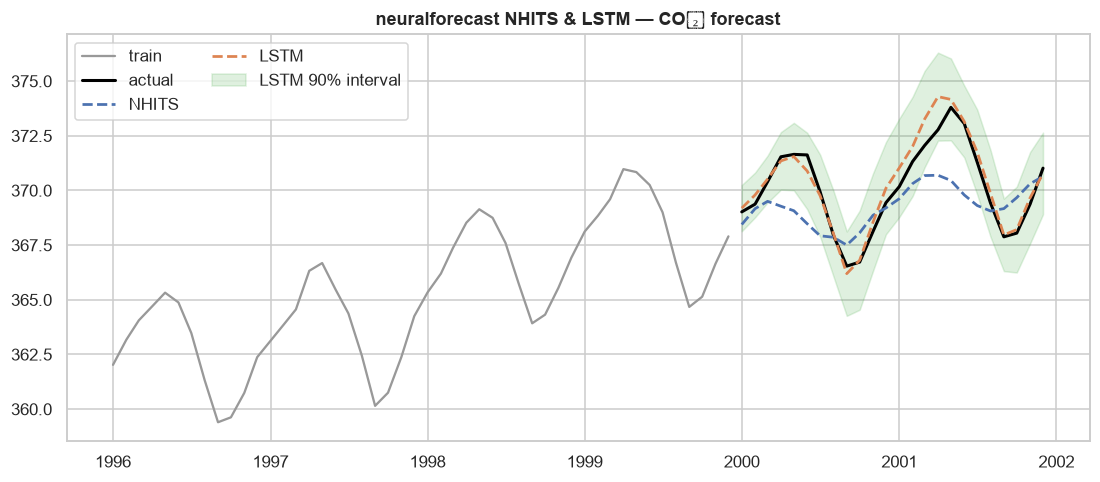

NHITS  90%-interval empirical coverage = 88%
LSTM   90%-interval empirical coverage = 100%


In [4]:
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(tr.index[-48:], tr.values[-48:], color="0.6", label="train")
ax.plot(te.index, te.values, color="black", lw=2, label="actual")
ax.plot(pred.index, pred["NHITS"], "--", lw=1.8, label="NHITS")
ax.plot(pred.index, pred["LSTM"], "--", lw=1.8, label="LSTM")
ax.fill_between(pred.index, pred["LSTM-lo-90"], pred["LSTM-hi-90"], color="tab:green", alpha=0.15, label="LSTM 90% interval")
ax.set_title("neuralforecast NHITS & LSTM — CO₂ forecast"); ax.legend(ncol=2)
eda.savefig(fig, "p10_nf_forecast.png"); plt.show()
for c in ["NHITS","LSTM"]:
    cov = ((te.values>=pred[c+"-lo-90"].values)&(te.values<=pred[c+"-hi-90"].values)).mean()
    print("%-6s 90%%-interval empirical coverage = %.0f%%" % (c, 100*cov))

### 4. The grand scoreboard — every model in the course

The same CO₂ 24-month holdout, every forecaster we've built: the two deep models vs the
from-scratch MLP (Part 9), LightGBM (Part 5), and the classical winners (Part 3).

In [5]:
d = tr.diff().dropna(); sup = mlf.make_supervised(d, n_lags=12); cols = mlf.feature_cols(sup)
mlp = nn.MLPRegressor(hidden=(64,32), epochs=600, lr=0.01, seed=0).fit(sup[cols].values, sup["y"].values)
p_mlp = mlf.reconstruct_from_diff(mlf.recursive_forecast(mlp, d, H, cols), tr.iloc[-1]).values
lgbm = lgb.LGBMRegressor(n_estimators=300, num_leaves=31, learning_rate=0.05,
                         min_child_samples=10, random_state=0, verbose=-1).fit(sup[cols], sup["y"])
p_lgbm = mlf.reconstruct_from_diff(mlf.recursive_forecast(lgbm, d, H, cols), tr.iloc[-1]).values
hw  = ExponentialSmoothing(tr, trend="add", seasonal="add", seasonal_periods=12).fit().forecast(H).values
sar = SARIMAX(tr, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False).forecast(H).values
board = fc.compare_models(te, {"NHITS": pred["NHITS"].values, "LSTM": pred["LSTM"].values,
                               "NumPy-MLP": p_mlp, "LGBM-diff": p_lgbm,
                               "Holt-Winters": hw, "SARIMA": sar}, tr, m=12)
print(board[["MAE","RMSE","MASE"]].to_string())

                 MAE    RMSE    MASE
Holt-Winters  0.2357  0.3070  0.1815
LGBM-diff     0.2931  0.3496  0.2257
SARIMA        0.3338  0.4095  0.2570
LSTM          0.4132  0.5505  0.3182
NumPy-MLP     0.4152  0.4984  0.3198
NHITS         1.3856  1.6956  1.0670


Read it honestly. **LSTM** is competitive — its sequence memory makes it the strongest of the
neural models and it edges the from-scratch MLP. **NHITS** underperforms here: it is engineered for
long, high-frequency, *many*-series problems and is over-powered and finicky on ~480 monthly points.
And the tuned **Holt-Winters still wins overall**. More architecture is not more accuracy when the
data is small and clean — the exact lesson of Parts 5 and 9, now confirmed with the real libraries.

### 5. So where do these models actually dominate?

Not here. They win in the regime they were built for:

- **Global training across thousands of series** — retail SKUs, sensors, every stock at once —
  where the network borrows strength across series and amortises its capacity.
- **High-frequency / long-horizon** data (hourly energy, web traffic) where there is enough signal
  to feed millions of parameters.
- **Rich exogenous covariates** and **probabilistic** output at scale.
- **Foundation models** (TimeGPT, Chronos, TimesFM) take this further — pretrained on millions of
  series, they forecast **zero-shot**, no training data required.

The decision rule the whole course has repeated: **baseline → classical → trees → deep**, climbing
only when the data's scale and structure justify it. On a single tidy seasonal line, you stop early.

### Takeaways

- **`neuralforecast` runs the real thing** — NHITS & LSTM on PyTorch — with built-in **conformal
  intervals** (Part 6's idea, native).
- **LSTM's recurrence** (hidden state through time) gives it sequence memory the Part-9 MLP lacks,
  making it the best of the neural models on CO₂; **NHITS** is mis-matched to this small series.
- **The classical Holt-Winters still wins** the grand scoreboard — deep models are **data- and
  scale-hungry**, not universally better.
- These models shine on **many series, high frequency, covariates, and scale**; **foundation
  models** push to zero-shot. Match the model to the data regime.

*This closes the forecasting arc end-to-end: baselines → ETS/ARIMA (3) → trees (5) → evaluation (6)
→ from-scratch nets (9) → production deep models (10), every one scored on the same holdout.*